# Warehouse Edition

This notebook builds two newsletter charts that frame market warehouse capacity through auction demand and credit allocation.

Data files used in this edition:
- `data/auction_tail_divergence.csv`
- `data/credit_allocation_spread.csv`

The current CSVs are compact working datasets aligned to the intended narrative and can be revised as official source extracts are finalized.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 7)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"

BASE_PATH = Path("data")
auction_df = pd.read_csv(BASE_PATH / "auction_tail_divergence.csv")
credit_df = pd.read_csv(BASE_PATH / "credit_allocation_spread.csv")

# To refresh U.S. Treasury auction data, run: python fetch_auction_data.py
print(f"Auction data: {len(auction_df)} rows ({int(auction_df['year'].min())}–{int(auction_df['year'].max())})")
print(f"Credit data:  {len(credit_df)} rows ({int(credit_df['year'].min())}–{int(credit_df['year'].max())})")
auction_df

Auction data: 11 rows (2016–2026)
Credit data:  11 rows (2014–2024)


,year,us_2y_bid_to_cover,us_5y_bid_to_cover
0,2016,2.928750,2.448462
1,2017,2.949375,2.449231
2,2018,2.880625,2.453846
3,2019,2.609375,2.431429
4,2020,2.723125,2.501429
5,2021,2.626875,2.387857
6,2022,2.682500,2.437143
7,2023,2.774375,2.494286
8,2024,2.795000,2.397143
9,2025,2.707500,2.375000


## Chart 1. U.S. Treasury Auction Demand: The Fatigue Signal

This chart tracks annual average bid-to-cover ratios for U.S. 2-Year and 5-Year Treasury auctions from 2016 to 2026. The gray band marks the pre-COVID normal range (2016–2019). The dashed danger zone at 2.3x marks the threshold where demand is no longer comfortably clearing new supply. Source: U.S. Treasury FiscalData API.


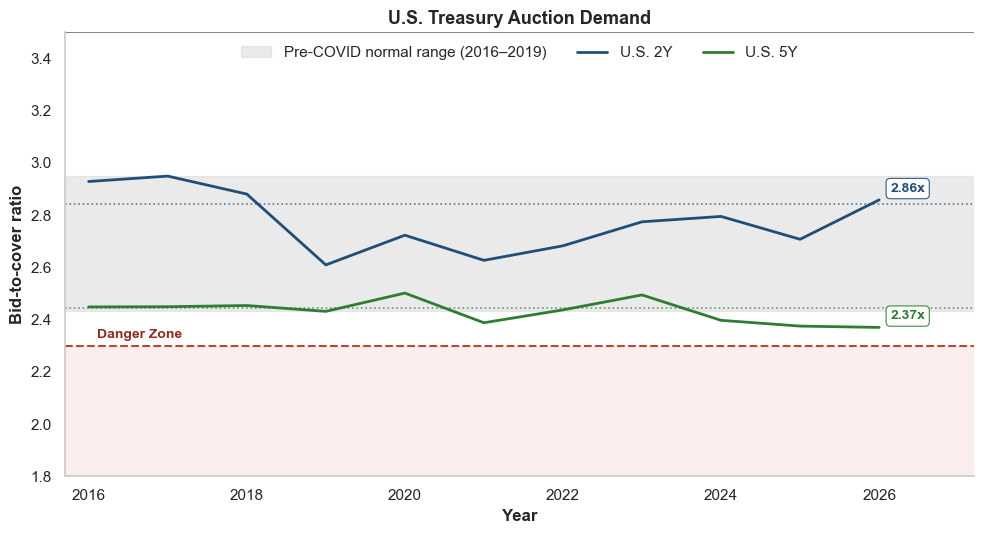

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

if "auction_df" not in dir():
    auction_df = pd.read_csv(Path("data") / "auction_tail_divergence.csv")

COLOR_2Y = "#1f4e79"   # dark navy    — U.S. 2Y
COLOR_5Y = "#2e7d32"   # forest green — U.S. 5Y

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.grid(False)

# --- Pre-COVID normal range (2016–2019) ---
pre_covid = auction_df[auction_df["year"] <= 2019]
normal_lo = min(
    pre_covid["us_2y_bid_to_cover"].min(),
    pre_covid["us_5y_bid_to_cover"].min(),
)
normal_hi = max(
    pre_covid["us_2y_bid_to_cover"].max(),
    pre_covid["us_5y_bid_to_cover"].max(),
)
ax.axhspan(normal_lo, normal_hi, color="#d9d9d9", alpha=0.55, label="Pre-COVID normal range (2016–2019)")

# --- Dotted mean reference lines ---
mean_2y = pre_covid["us_2y_bid_to_cover"].mean()
mean_5y = pre_covid["us_5y_bid_to_cover"].mean()
ax.axhline(mean_2y, color=COLOR_2Y, linestyle=":", linewidth=1.2, alpha=0.7)
ax.axhline(mean_5y, color=COLOR_5Y, linestyle=":", linewidth=1.2, alpha=0.7)

# --- Danger zone ---
danger_zone = 2.3
ax.axhspan(1.8, danger_zone, color="#f4c7c3", alpha=0.30)
ax.axhline(danger_zone, color="#b24a3a", linestyle="--", linewidth=1.5)
ax.text(
    auction_df["year"].min() + 0.1,
    danger_zone + 0.03,
    "Danger Zone",
    color="#8f2d20",
    fontsize=10,
    fontweight="bold",
)

# --- US 2Y and 5Y lines ---
ax.plot(
    auction_df["year"],
    auction_df["us_2y_bid_to_cover"],
    label="U.S. 2Y",
    color=COLOR_2Y,
    linewidth=2,
)
ax.plot(
    auction_df["year"],
    auction_df["us_5y_bid_to_cover"],
    label="U.S. 5Y",
    color=COLOR_5Y,
    linewidth=2,
)

# --- Latest value annotations ---
latest = auction_df.iloc[-1]
latest_year = latest["year"]
ax.annotate(
    f"{latest['us_2y_bid_to_cover']:.2f}x",
    (latest_year, latest["us_2y_bid_to_cover"]),
    xytext=(8, 6),
    textcoords="offset points",
    color=COLOR_2Y,
    fontsize=10,
    fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor=COLOR_2Y, linewidth=0.8, alpha=0.9),
)
ax.annotate(
    f"{latest['us_5y_bid_to_cover']:.2f}x",
    (latest_year, latest["us_5y_bid_to_cover"]),
    xytext=(8, 6),
    textcoords="offset points",
    color=COLOR_5Y,
    fontsize=10,
    fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor=COLOR_5Y, linewidth=0.8, alpha=0.9),
)

ax.set_title("U.S. Treasury Auction Demand", fontsize=13, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Bid-to-cover ratio")
ax.set_ylim(1.8, 3.5)
ax.set_yticks([1.8, 2.0, 2.2, 2.4, 2.6, 2.8, 3.0, 3.2, 3.4])
ax.set_xlim(auction_df["year"].min() - 0.3, auction_df["year"].max() + 1.2)
ax.axhline(3.5, color="#888888", linewidth=0.8)
ax.legend(frameon=False, loc="upper center", ncols=3, bbox_to_anchor=(0.5, 1.0))
plt.tight_layout()
plt.show()


## Chart 2. Public vs. Private Credit Growth

This chart frames crowding-out through a simple spread: sovereign paper as a share of bank assets climbs while private-sector credit growth fades toward zero. The annotations show the change in warehouse mix from 50% to 80% sovereign exposure. Source: World Bank Open Data API.


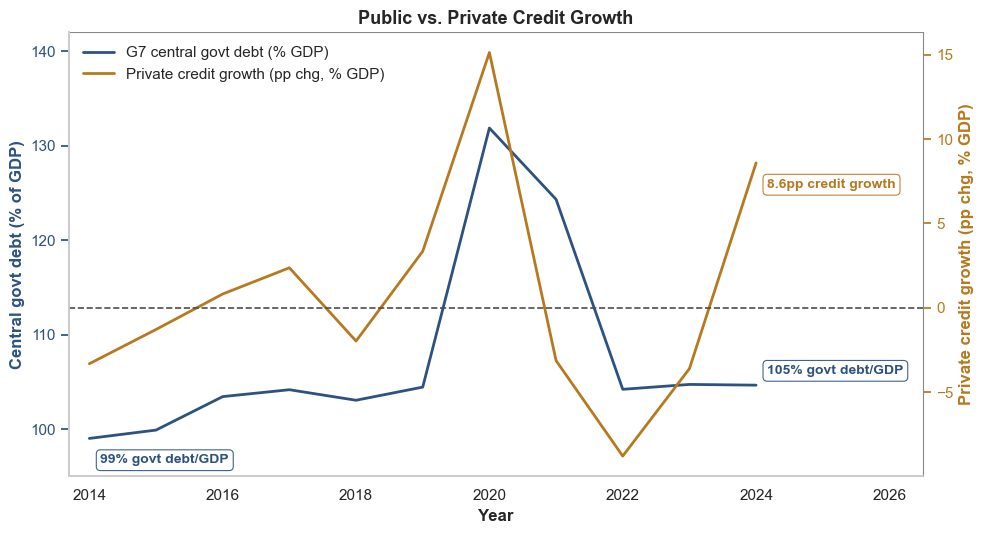

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

if "credit_df" not in dir():
    credit_df = pd.read_csv(Path("data") / "credit_allocation_spread.csv")

COLOR_SOV  = "#2c5282"   # deep slate blue — sovereign debt
COLOR_PRIV = "#b7791f"   # amber           — private credit

fig, ax_left = plt.subplots(figsize=(10, 5.5))
ax_right = ax_left.twinx()
ax_left.grid(False)
ax_right.grid(False)

ax_left.plot(
    credit_df["year"],
    credit_df["g7_sovereign_share_bank_assets"],
    color=COLOR_SOV,
    linewidth=2,
    label="G7 central govt debt (% GDP)",
)
ax_right.plot(
    credit_df["year"],
    credit_df["private_credit_growth"],
    color=COLOR_PRIV,
    linewidth=2,
    label="Private credit growth (pp chg, % GDP)",
)

ax_right.axhline(0, color="#4d4d4d", linestyle="--", linewidth=1.2)

first_year = credit_df.iloc[0]
last_year  = credit_df.iloc[-1]

BBOX = dict(boxstyle="round,pad=0.3", facecolor="white", linewidth=0.8, alpha=0.9)

ax_left.annotate(
    f"{first_year['g7_sovereign_share_bank_assets']:.0f}% govt debt/GDP",
    (first_year["year"], first_year["g7_sovereign_share_bank_assets"]),
    xytext=(8, -18),
    textcoords="offset points",
    fontsize=10,
    fontweight="bold",
    color=COLOR_SOV,
    bbox={**BBOX, "edgecolor": COLOR_SOV},
)
ax_left.annotate(
    f"{last_year['g7_sovereign_share_bank_assets']:.0f}% govt debt/GDP",
    (last_year["year"], last_year["g7_sovereign_share_bank_assets"]),
    xytext=(8, 8),
    textcoords="offset points",
    fontsize=10,
    fontweight="bold",
    color=COLOR_SOV,
    bbox={**BBOX, "edgecolor": COLOR_SOV},
)
ax_right.annotate(
    f"{last_year['private_credit_growth']:.1f}pp credit growth",
    (last_year["year"], last_year["private_credit_growth"]),
    xytext=(8, -18),
    textcoords="offset points",
    fontsize=10,
    color=COLOR_PRIV,
    fontweight="bold",
    bbox={**BBOX, "edgecolor": COLOR_PRIV},
)

ax_left.set_title("Public vs. Private Credit Growth", fontsize=13, fontweight="bold")
ax_left.set_xlabel("Year")
ax_left.set_ylabel("Central govt debt (% of GDP)", color=COLOR_SOV)
ax_right.set_ylabel("Private credit growth (pp chg, % GDP)", color=COLOR_PRIV)
ax_left.tick_params(axis="y", colors=COLOR_SOV)
ax_right.tick_params(axis="y", colors=COLOR_PRIV)

ax_left.set_ylim(95, 142)
ax_left.set_yticks([100, 110, 120, 130, 140])
ax_left.set_xlim(credit_df["year"].min() - 0.3, credit_df["year"].max() + 2.5)
ax_left.axhline(142, color="#888888", linewidth=0.8)

ax_right.spines["right"].set_visible(True)
ax_right.spines["right"].set_color("#888888")
ax_right.spines["right"].set_linewidth(0.8)

lines_left,  labels_left  = ax_left.get_legend_handles_labels()
lines_right, labels_right = ax_right.get_legend_handles_labels()
ax_left.legend(lines_left + lines_right, labels_left + labels_right, frameon=False, loc="upper left")

plt.tight_layout()
plt.show()
